In [1]:
import os
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from tqdm import tqdm
import pickle
import sklearn.metrics as skm
from sklearn.model_selection import train_test_split
from scipy.stats import ks_2samp
import math
import shap
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression

# catboost
try:
    import catboost as cb
except:
    ! pip install catboost
    import catboost as cb

# xg boost
try:
    import xgboost as xbm
except:
    ! pip install xgboost
    import xgboost as xbm

/home/ec2-user/anaconda3/envs/python3/lib/python3.10/site-packages/xgboost/core.py:265: FutureWarning: Your system has an old version of glibc (< 2.28). We will stop supporting Linux distros with glibc older than 2.28 after **May 31, 2025**. Please upgrade to a recent Linux distro (with glibc 2.28+) to use future versions of XGBoost.
Note: You have installed the 'manylinux2014' variant of XGBoost. Certain features such as GPU algorithms or federated learning are not available. To use these features, please upgrade to a recent Linux distro with glibc 2.28+, and install the 'manylinux_2_28' variant.
  warnings.warn(


#### Functions

In [2]:
def target_by_data_set(df, str_target):
    df_tmp = df.groupby(by='data_set', as_index=False).agg({
        str_target: 'mean',
    })
    df_tmp['sort'] = df_tmp['data_set'].map(dict_sort)
    df_tmp.sort_values(by='sort', ascending=True, inplace=True)
    df_tmp.drop('sort', axis=1, inplace=True)

    # plot
    x = df_tmp['data_set']
    y = df_tmp[str_target]
    fig, ax = plt.subplots(figsize=(9,5))
    ax.set_title(f'Mean {str_target} by Data Set')
    ax.set_xlabel('Data Set')
    ax.set_ylabel(f'Mean {str_target}')
    # bars
    bars = ax.bar(x, y)
    # add labels to the bars
    ax.bar_label(bars, fmt='%.4f')
    # show
    plt.show()

In [3]:
def target_by_feature(df, str_col, str_target):
    df_tmp = df[df['data_set'] == 'train'].groupby(by=str_col, as_index=False).agg({
        str_target: 'mean',
    })

    # plot
    x = df_tmp[str_col].astype(str)
    y = df_tmp[str_target]
    fig, ax = plt.subplots(figsize=(9,5))
    ax.set_title(f'Mean {str_target} by {str_col}')
    ax.set_xlabel('Data Set')
    ax.set_ylabel(f'Mean {str_target}')
    # bars
    bars = ax.bar(x, y)
    # add labels to the bars
    ax.bar_label(bars, fmt='%.4f')
    # show
    plt.show()

In [4]:
def target_by_feature_quantile(df, str_col, int_n_quantiles, str_target):
    # get quantile
    df_tmp = df[df['data_set'] == 'train'].copy()
    # replace infs with nan
    df_tmp[str_col] = df_tmp[str_col].replace(np.inf, np.nan)
    # drop missing rows
    df_tmp = df_tmp.dropna(subset=[str_col])
    # get quantile
    df_tmp['quantile'] = pd.qcut(df_tmp[str_col], q=int_n_quantiles, duplicates='drop')
    # min-max
    df_tmp['min'] = df_tmp[str_col]
    df_tmp['max'] = df_tmp[str_col]
    # get target mean by quangtile
    df_tmp = df_tmp.groupby(by='quantile', as_index=False).agg({
        'min': 'min',
        'max': 'max',
        str_target: 'mean',
    })
    # sort
    df_tmp.sort_values(by='min', ascending=True, inplace=True)
    # rank
    df_tmp['quantile'] = range(1, df_tmp.shape[0]+1)
    # plot
    fig, ax = plt.subplots(figsize=(9,5))
    ax.set_title(f'{str_target} by {str_col} Quantile')
    ax.set_xlabel(f'{str_col} Quantile')
    ax.set_ylabel(str_target)
    ax.plot(df_tmp['quantile'].astype(str), df_tmp[str_target])
    plt.show()

In [5]:
def get_suggested_constraints(df, list_cols_model, str_target, int_n_quantiles):
    list_dict_row = []
    for col in tqdm(list_cols_model):
        # df_tmp
        df_tmp = df.copy()
        # replace infs with nan
        df_tmp[col] = df_tmp[col].replace(np.inf, np.nan)
        # drop missing rows
        df_tmp = df_tmp.dropna(subset=[col])
        # get number of unique values
        int_n_unique = df_tmp[col].nunique()
        # logic
        if int_n_unique <= int_n_quantiles:
            # create a feature named quantile
            df_tmp['quantile'] = df_tmp[str_col]
        else:
            # get quantile
            df_tmp['quantile'] = pd.qcut(df_tmp[col], q=int_n_quantiles, duplicates='drop')
        # min-max
        df_tmp['min'] = df_tmp[col]
        df_tmp['max'] = df_tmp[col]
        # get target mean by quangtile
        df_tmp = df_tmp.groupby(by='quantile', as_index=False).agg({
            'min': 'min',
            'max': 'max',
            str_target: 'mean',
        })
        # sort
        df_tmp.sort_values(by='min', ascending=True, inplace=True)
        # create rank column
        df_tmp['rank'] = range(1, df_tmp.shape[0]+1)
        # fit trend line
        flt_slope, flt_intercept = np.polyfit(x=df_tmp['rank'], y=df_tmp[str_target], deg=1)
        # logic for monotone contraints
        if flt_slope > 0:
            int_constraint = 1
            str_imputation = 'max'
        else:
            int_constraint = -1
            str_imputation = 'min'
        # make a row
        dict_row = {
            'feature': col,
            'intercept': flt_intercept,
            'slope': flt_slope,
            'constraint': int_constraint,
            'imputation': str_imputation,
        }
        list_dict_row.append(dict_row)
    # make a df
    df = pd.DataFrame(list_dict_row)
    # return
    return df

In [6]:
class OverSampling:
    def __init__(self, df, str_target, flt_target_value, flt_current_value):
        self.df = df
        self.str_target = str_target
        self.flt_target_value = flt_target_value
        self.flt_current_value = flt_current_value
    # oversample zeros
    def oversample_zeros(self):
        # get n zeros
        df_zeros = self.df[self.df[str_target] == 0].copy()
        int_n_zeros_original = df_zeros.shape[0]
        # get n ones
        df_ones = self.df[self.df[str_target] == 1].copy()
        int_n_ones_original = df_ones.shape[0]
        # get total
        int_n_total_original = int_n_zeros_original + int_n_ones_original
        # solve for the new n total to reach target
        int_n_total_new = math.ceil(int_n_ones_original / flt_target_value)
        # get n additional 0s
        int_n_additional_zeros = int_n_total_new - int_n_ones_original - int_n_zeros_original
        # get sample
        df_zeros_additional = df_zeros.sample(n=int_n_additional_zeros, random_state=42)
        # concat
        df = pd.concat([df_zeros, df_ones, df_zeros_additional])
        # shuffle
        df = df.sample(frac=1.0, random_state=42)
        # return
        return df 
    # undersample ones
    def oversample_ones(self):
        # get n zeros
        df_zeros = self.df[self.df[str_target] == 0].copy()
        int_n_zeros_original = df_zeros.shape[0]
        # get n ones
        df_ones = self.df[self.df[str_target] == 1].copy()
        int_n_ones_original = df_ones.shape[0]
        # get total
        int_n_total_original = int_n_zeros_original + int_n_ones_original
        # solve for number of 1s
        int_n_additional_ones = math.ceil((int_n_ones_original - (flt_target_value * int_n_total_original)) / (flt_target_value - 1))
        # get sample
        df_ones_additional = df_ones.sample(n=int_n_additional_ones, random_state=42)
        # concat
        df = pd.concat([df_zeros, df_ones, df_ones_additional])
        # shuffle
        df = df.sample(frac=1.0, random_state=42)
        # return
        return df
    # sample
    def sample(self):
        # logic
        if self.flt_target_value < self.flt_current_value:
            df = self.oversample_zeros()
        else:
            df = self.oversample_ones()
        # return
        return df

In [7]:
class UnderSampling:
    def __init__(self, df, str_target, flt_target_value, flt_current_value):
        self.df = df
        self.str_target = str_target
        self.flt_target_value = flt_target_value
        self.flt_current_value = flt_current_value
    # undersample ones
    def undersample_ones(self):
        # get df zeros
        df_zeros = self.df[self.df[self.str_target] == 0].copy()
        # get number of zeroes
        int_n_zeros = df_zeros.shape[0]
        # solve for number of 1s needed to reach target (str_target_value = x/(int_n_zeros + x))
        int_n_ones = math.ceil((self.flt_target_value * int_n_zeros) / (1 - self.flt_target_value))
        # subset to 1s
        df_ones = self.df[self.df[self.str_target] == 1].copy()
        # random subset
        df_ones = df_ones.sample(n=int_n_ones, random_state=42)
        # concat
        df = pd.concat([df_zeros, df_ones])
        # shuffle
        df = df.sample(frac=1.0, random_state=42)
        # return
        return df 
    # undersample zeros
    def undersample_zeros(self):
        # get df ones
        df_ones = self.df[self.df[str_target] == 1].copy()
        # get number of ones
        int_n_ones = df_ones.shape[0]
        # solve for number of 0s needed to reach target
        int_n_zeros = math.ceil((int_n_ones - (self.flt_target_value * int_n_ones)) / self.flt_target_value)
        # subset to 0s
        df_zeros = self.df[self.df[self.str_target] == 0].copy()
        # random subset
        df_zeros = df_zeros.sample(n=int_n_zeros, random_state=42)
        # concat
        df = pd.concat([df_ones, df_zeros])
        # shuffle
        df = df.sample(frac=1.0, random_state=42)
        # return
        return df
    # sample
    def sample(self):
        # logic
        if self.flt_target_value < self.flt_current_value:
            df = self.undersample_ones()
        else:
            df = self.undersample_zeros()
        # return
        return df

In [8]:
# get xgb feat importance
def get_xgboost_feat_importance(cls_model_inference):
    cls_booster = cls_model_inference.get_booster()
    dict_feat_imp = cls_booster.get_score(importance_type='gain')
    ser_feat_imp = pd.Series(dict_feat_imp)
    df_tmp = ser_feat_imp.reset_index()
    df_tmp.columns = ['feature', 'importance']
    df_tmp.sort_values(by='importance', ascending=False, inplace=True)
    return df_tmp

In [9]:
def get_catboost_feat_importance(cls_model_inference, pool_eval):
    df_tmp = cls_model_inference.get_feature_importance(
        data=pool_eval,
        type='LossFunctionChange',
        prettified=True,
    )
    df_tmp.columns = ['feature', 'importance']
    df_tmp.sort_values(by='importance', ascending=False, inplace=True)
    return df_tmp

In [10]:
def get_logistic_regression_feat_importance(cls_model_inference):
    df_tmp = pd.DataFrame({
        'feature': list(cls_model_inference.feature_names_in_),
        'importance': list(cls_model_inference.coef_[0]),
    })
    df_tmp['importance_abs'] = df_tmp['importance'].apply(abs)
    df_tmp.sort_values(by='importance_abs', ascending=False, inplace=True)
    # return
    return df_tmp

In [11]:
# min max scale
def min_max_scale(ser_values):
    # get min
    flt_min = ser_values.min()
    # get max
    flt_max = ser_values.max()
    # range
    flt_range = flt_max - flt_min
    # subtract min
    ser_values = ser_values - flt_min
    # divide by range
    ser_values = ser_values / flt_range
    # return
    return ser_values

In [12]:
def get_scaled_score(df):
    df['flt_eval_metric_valid_scaled'] = min_max_scale(df['flt_eval_metric_valid'])
    df['diff'] = df['flt_eval_metric_train'] - df['flt_eval_metric_valid']
    df['diff_scaled'] = 1 - min_max_scale(df['diff'])
    df['n_feats_scaled'] = 1 - min_max_scale(df['n_feats'])
    list_cols = [
        'flt_eval_metric_valid_scaled',
        'diff_scaled',
        #'n_feats_scaled',
    ]
    df['score'] = df[list_cols].mean(axis=1)
    df.sort_values(by='score', ascending=False, inplace=True)
    return df

In [13]:
# get shap values
def get_shap(cls_model_inference, X, list_cols_model):
    cls_explainer = shap.Explainer(cls_model_inference)
    df_tmp = pd.DataFrame(
        cls_explainer.shap_values(X[list_cols_model]),
        columns=list_cols_model,
    )
    # get avg by col
    ser_mean = df_tmp.mean()
    df_tmp = ser_mean.reset_index()
    df_tmp.columns = ['feature','importance']
    df_tmp['importance'] = df_tmp['importance'].apply(abs)
    # sort
    df_tmp.sort_values(by='importance', ascending=False, inplace=True)
    # return
    return df_tmp

In [14]:
# ks
def get_ks_score(y_true, y_pred):
    # make df
    df_tmp = pd.DataFrame({
        'y_true': y_true,
        'y_pred': y_pred,
    })
    # get mean of y_true
    flt_mean = df_tmp['y_true'].mean()
    # sort
    df_tmp.sort_values(by='y_pred', ascending=False, inplace=True)
    # make row number
    df_tmp['row'] = range(1, df_tmp.shape[0]+1)
    df_tmp['prop_row'] = df_tmp['row'] / df_tmp.shape[0]
    df_tmp['yhat_class'] = df_tmp['y_pred'].apply(
        lambda x: 1 if x <= flt_mean else 0,
    )
    # separate predictions by true class
    ser_pos_scores = df_tmp[df_tmp['y_true'] == 1]['yhat_class']
    ser_neg_scores = df_tmp[df_tmp['y_true'] == 0]['yhat_class']
    # Calculate KS statistic
    ks_stat, p_value = ks_2samp(ser_pos_scores, ser_neg_scores)
    return ks_stat

In [15]:
def evaluate(y_train, list_predictions_train, y_test, list_predictions_test, y_holdout, list_predictions_holdout):
    # get auc
    flt_auc_train = skm.roc_auc_score(
        y_true=y_train,
        y_score=list_predictions_train,
    )
    print(f'AUC Train: {flt_auc_train:0.4f}')
    flt_auc_test = skm.roc_auc_score(
        y_true=y_test,
        y_score=list_predictions_test,
    )
    print(f'AUC Test: {flt_auc_test:0.4f}')
    flt_auc_holdout = skm.roc_auc_score(
        y_true=y_holdout,
        y_score=list_predictions_holdout,
    )
    print(f'AUC Holdout: {flt_auc_holdout:0.4f}')
    print()
    # logloss
    flt_logloss_train = skm.log_loss(
        y_true=y_train,
        y_pred=list_predictions_train,
    )
    print(f'Logloss Train: {flt_logloss_train:0.4f}')
    flt_logloss_test = skm.log_loss(
        y_true=y_test,
        y_pred=list_predictions_test,
    )
    print(f'Logloss Test: {flt_logloss_test:0.4f}')
    flt_logloss_holdout = skm.log_loss(
        y_true=y_holdout,
        y_pred=list_predictions_holdout,
    )
    print(f'Logloss Holdout: {flt_logloss_holdout:0.4f}')
    print()
    # ks
    flt_ks_train = get_ks_score(
        y_true=y_train,
        y_pred=list_predictions_train,
    )
    print(f'KS Train: {flt_ks_train:0.4f}')
    flt_ks_test = get_ks_score(
        y_true=y_test,
        y_pred=list_predictions_test,
    )
    print(f'KS Test: {flt_ks_test:0.4f}')
    flt_ks_holdout = get_ks_score(
        y_true=y_holdout,
        y_pred=list_predictions_holdout,
    )
    print(f'KS Holdout: {flt_ks_holdout:0.4f}')

In [16]:
def get_directions_of_predictions(X, list_predictions, str_target, list_actual, list_cols, int_n_quantiles):
    # assign predictions
    X['yhat'] = list_predictions
    # assign actual
    X[str_target] = list_actual
    # iterate and plot
    for col in tqdm(list_cols):
        # get number of unique values
        int_n_unique = X[col].nunique()
        # logic
        if int_n_unique <= int_n_quantiles:
            # create a feature named quantile
            X['quantile'] = X[col]
        else:
            # get quantile
            X['quantile'] = pd.qcut(X[col], q=int_n_quantiles, duplicates='drop')
        # get target mean by quantile
        X['min'] = X[col]
        # group
        df_tmp = X.groupby(by='quantile', as_index=False).agg({
            'min': 'min',
            'yhat': 'mean',
            str_target: 'mean',
            
        })
        # sort
        df_tmp.sort_values(by='min', ascending=True, inplace=True)
        # rank
        df_tmp['quantile'] = range(1, df_tmp.shape[0]+1)
        # plot
        fig, ax = plt.subplots(figsize=(9,5))
        ax.set_title(f'Mean Predicted and Actual by {col} Quantile')
        ax.set_xlabel(f'{col} Quantile')
        ax.set_ylabel(str_target)
        # predicted
        ax.plot(df_tmp['quantile'].astype(str), df_tmp['yhat'], label='Predicted')
        # actual
        ax.plot(df_tmp['quantile'].astype(str), df_tmp[str_target], label='Actual')
        # legend
        ax.legend()
        # show
        plt.show()

In [17]:
def get_mean_actual_by_prediction_quantile(X, list_predictions, list_actual, str_target, int_n_quantiles, str_model_type):
    # assign
    X['yhat'] = list_predictions
    X[str_target] = list_actual
    # get quantile
    X['quantile'] = pd.qcut(X['yhat'], q=int_n_quantiles, duplicates='drop')
    # get min
    X['min'] = X['yhat']
    X['predicted'] = X['yhat']
    # group
    df_tmp = X.groupby(by='quantile', as_index=False).agg({
        'min': 'min',
        'predicted': 'mean',
        str_target: 'mean',
    })
    # sort
    df_tmp.sort_values(by='min', ascending=True, inplace=True)
    # create rank
    df_tmp['quantile'] = range(1, df_tmp.shape[0]+1)
    # plot
    fig, ax = plt.subplots(figsize=(9,5))
    ax.set_title(f'Mean {str_target} by {str_model_type} Prediction Quantile')
    ax.set_xlabel('Prediction Quantile')
    ax.set_ylabel(f'Mean {str_target}')
    ax.plot(df_tmp['quantile'].astype(str), df_tmp[str_target], label='Actual')
    ax.plot(df_tmp['quantile'].astype(str), df_tmp['predicted'], label='Predicted')
    # legend
    ax.legend()
    # show
    plt.show()

#### Constants

In [18]:
str_project = os.getcwd().split('/')[4].replace('_','-')
print(f'Project: {str_project}')

str_task = os.getcwd().split('/')[5]
print(f'Task: {str_task}')

str_subtask = os.getcwd().split('/')[6]
print(f'Subtask: {str_subtask}')

str_target_tmp = str_task[3:].replace('_in_','_')
str_target = f'Early_Pay_Delinquency_{str_target_tmp}_Flag'
print(f'Target: {str_target}')

# for ordering
dict_sort = {
    'train': 1,
    'valid': 2,
    'test': 3,
    'inform': 4,
    'holdout': 5,
}

# limit for proporiton nan
flt_threshold_nan = 0.50

int_n_iterations = 1000
int_n_early_stopping = 50

Project: 20241112-simple-model-test
Task: 10_60_in_720
Subtask: 02_model
Target: Early_Pay_Delinquency_60_720_Flag


#### Output directory

In [19]:
try:
    os.mkdir(str_dirname_output)
except:
    pass

#### Get data dictionary for mapping descriptions

In [20]:
str_filename = 'data_dictionary.csv'
str_local_path = f'../../data_dictionary/{str_filename}'
df_tmp = pd.read_csv(str_local_path)
dict_map_descriptions = dict(zip(df_tmp['feature_name'], df_tmp['Description']))

#### Get TU scorecard features

In [21]:
str_filename = 'df_tu_scorecard_features.csv'
str_local_path = f'../../scorecard_features/{str_filename}'
df_tmp = pd.read_csv(str_local_path)
# get features
list_cols_tu = list(df_tmp['feature'])
print(f'There are {len(list_cols_tu)} unique TU scorecard features')

# show
df_tmp

There are 51 unique TU scorecard features


,feature,1_open_bk,2_thick_and_dirty,3_thick_and_clean,4_thin,sum
0,g106s__tu,1.0,1.0,1.0,1.0,4.0
1,balmag01__tu,0.0,1.0,1.0,1.0,3.0
2,g251b__tu,0.0,1.0,1.0,1.0,3.0
3,re01s__tu,0.0,1.0,1.0,1.0,3.0
4,g232s__tu,1.0,0.0,1.0,0.0,2.0
5,rtl_trd__tu,1.0,0.0,0.0,1.0,2.0
6,au20s__tu,1.0,0.0,0.0,1.0,2.0
7,p02g__tu,0.0,0.0,1.0,1.0,2.0
8,g213b__tu,0.0,1.0,1.0,0.0,2.0
9,p02b__tu,1.0,0.0,1.0,0.0,2.0


#### Import data

In [22]:
list_cols_import = [
    'data_set',
    'days_on_books',
    'applicationdate__app',
    'accountid',
    'strdealershiptrackertype__app',
    'bitdebtor__app',
    str_target,
    'fltgrossmonthly__income_sum', # income
    'flt_payment_open__tu_pmthx',
    'ENG-franchise',
    'ENG-has_codebtor',
    'ENG-vehicle_age',
    'ENG-payment_to_income', # payment to income
    'ENG-loan_to_value', # loan to value
    'ENG-bk', # bk
    'dti__app', # debt to income
    # pmt hx
    'flt_mean_months_to_first_bad__tu_pmthx', # avg proportion of months to first bad pmt (low is bad)
    # open
    'flt_payment_open__tu_pmthx',
    'int_n_months_open__tu_pmthx',
    'flt_wtd_avg_open__tu_pmthx', # weighted avg of most recent open (low is bad)
    'flt_avg_open__tu_pmthx', # avg of most recent open (low is bad)
    'int_30dpd_open__tu_pmthx', # n times 30 dpd of most recent open
    'int_60dpd_open__tu_pmthx', # n times 60 dpd of most recent open
    'int_90dpd_open__tu_pmthx', # n times 90 dpd of most recent open
    # closed
    'int_n_months_closed__tu_pmthx',
    'flt_wtd_avg_closed__tu_pmthx',
    'flt_avg_closed__tu_pmthx',
    'int_30dpd_closed__tu_pmthx',
    'int_60dpd_closed__tu_pmthx',
    'int_90dpd_closed__tu_pmthx',
    # handpicked
    're01s__tu', # top feature in PD - number of revolving trades
    'g990s__tu', # highest shap in PD
    'g106s__tu', # in all 4 scorecards
    'addrinputtimenewest__ln', # Time on file (in months) since the subject was most recently reported at the input address
    'linka029__tu', # checking account inquiries
    'au25s__tu', # pmt hx
    'au27s__tu', # pmt hx
    'g980s__tu',
    'bkc321__tu',
    'balmag01__tu',
    'at28b__tu',
    'addrlastmovetaxratiodiff__ln',
    'at35a__tu',
]
# add tu
#list_cols_import = list_cols_import + list_cols_tu
# rm dups
list_cols_import = list(dict.fromkeys(list_cols_import))
# import
list_str_filename = [
    'train',
    'valid',
    'test',
    'inform',
    'holdout',
]
list_df = []
for str_filename in tqdm(list_str_filename):
    str_filename_tmp = f'df_{str_filename}.gzip'
    str_uri = f's3://{str_project}/{str_task}/01_data_split/{str_filename_tmp}'
    df = pd.read_parquet(
        str_uri,
        columns=list_cols_import,
    )
    # logic
    if str_filename in ['train','valid','test','inform']:
        df['data_set'] = 'train'
    else:
        pass
    # append
    list_df.append(df)
# concatenate
df = pd.concat(list_df)
# save memory
del list_df
# show
df

  0%|          | 0/5 [00:00<?, ?it/s]/home/ec2-user/anaconda3/envs/python3/lib/python3.10/site-packages/fsspec/registry.py:279: UserWarning: Your installed version of s3fs is very old and known to cause
severe performance issues, see also https://github.com/dask/dask/issues/10276

To fix, you should specify a lower version bound on s3fs, or
update the current installation.

  warnings.warn(s3_msg)
100%|██████████| 5/5 [00:07<00:00,  1.50s/it]


,data_set,days_on_books,applicationdate__app,accountid,strdealershiptrackertype__app,bitdebtor__app,Early_Pay_Delinquency_60_720_Flag,fltgrossmonthly__income_sum,flt_payment_open__tu_pmthx,ENG-franchise,...,addrinputtimenewest__ln,linka029__tu,au25s__tu,au27s__tu,g980s__tu,bkc321__tu,balmag01__tu,at28b__tu,addrlastmovetaxratiodiff__ln,at35a__tu
175,train,1215,2021-07-22 17:37:28.093,5716209,Franchise,1,0,7000.0,NaN,1,...,1.0,2.0,-1.0,-1.0,1.0,1.0,392.0,9325.0,0.0,3198.0
154,train,1215,2021-07-07 12:49:20.480,5702150,Franchise,1,0,7500.0,NaN,1,...,1.0,0.0,-3.0,-3.0,3.0,103.0,415.0,5775.0,-1.0,1015.0
18,train,1218,2021-07-07 12:17:51.430,5702106,Franchise,1,0,8500.0,NaN,1,...,1.0,NaN,-3.0,-3.0,1.0,-1.0,-2.0,-3.0,-1.0,-3.0
207,train,1215,2021-07-21 13:45:49.677,5714824,Franchise,0,1,4500.0,501.0,1,...,1.0,4.0,1.0,-6.0,5.0,-1.0,94.0,21829.0,0.0,9729.0
206,train,1215,2021-07-21 13:45:49.677,5714824,Franchise,1,1,3500.0,364.0,1,...,1.0,5.0,-3.0,-3.0,4.0,-2.0,-2.0,-3.0,0.0,-3.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
42089,holdout,721,2022-11-28 12:25:18.957,6464887,Franchise,1,0,5000.0,NaN,1,...,1.0,1.0,-3.0,-3.0,5.0,170.0,204.0,3250.0,-1.0,165.0
42197,holdout,720,2022-11-28 11:17:53.530,6464638,Independent,1,0,3000.0,NaN,0,...,-1.0,1.0,-3.0,-3.0,5.0,319.0,254.0,54160.0,-1.0,4152.0
41923,holdout,725,2022-11-28 10:17:32.573,6464416,Independent,1,0,4000.0,713.0,0,...,26.0,0.0,1.0,1.0,1.0,-2.0,34.0,25727.0,0.0,9519.0
42062,holdout,722,2022-11-28 15:09:59.617,6465473,Franchise,1,0,4000.0,NaN,1,...,-1.0,NaN,-3.0,-3.0,1.0,-1.0,300.0,-3.0,0.0,-3.0


#### Target mean by data set

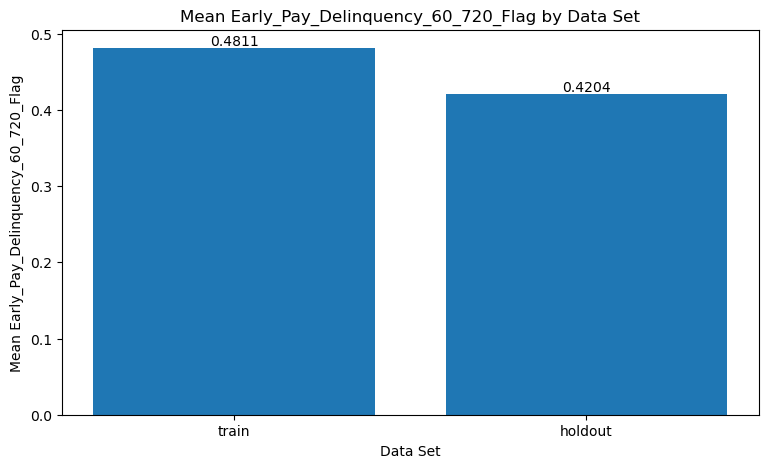

In [23]:
target_by_data_set(
    df=df,
    str_target=str_target,
)

#### Target mean by BK

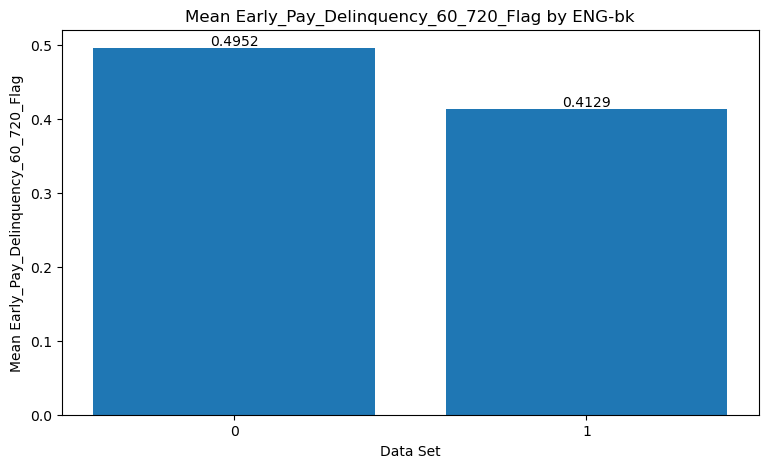

In [24]:
str_col = 'ENG-bk'
target_by_feature(
    df=df, 
    str_col=str_col,
    str_target=str_target,
)

#### Target mean by dealer type

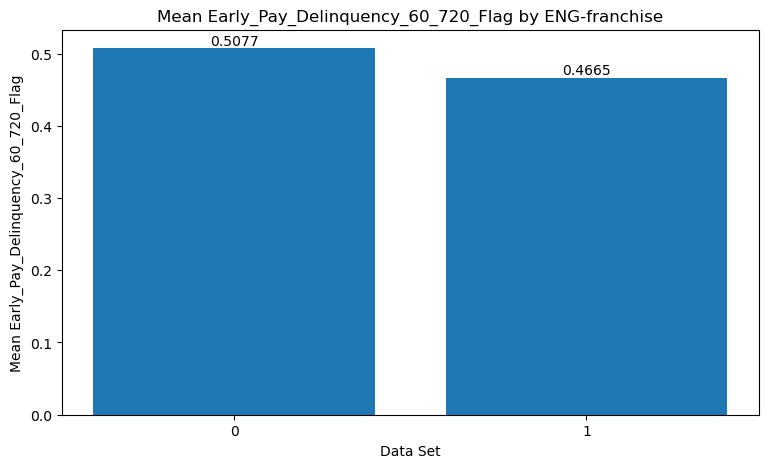

In [25]:
str_col = 'ENG-franchise'
target_by_feature(
    df=df, 
    str_col=str_col,
    str_target=str_target,
)

#### Target mean by has a codebtor

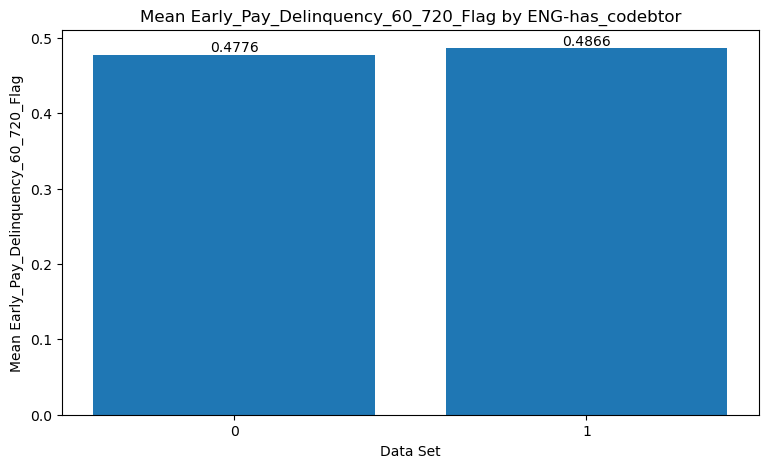

In [26]:
str_col = 'ENG-has_codebtor'
target_by_feature(
    df=df, 
    str_col=str_col,
    str_target=str_target,
)

#### Target by LTV Quantile

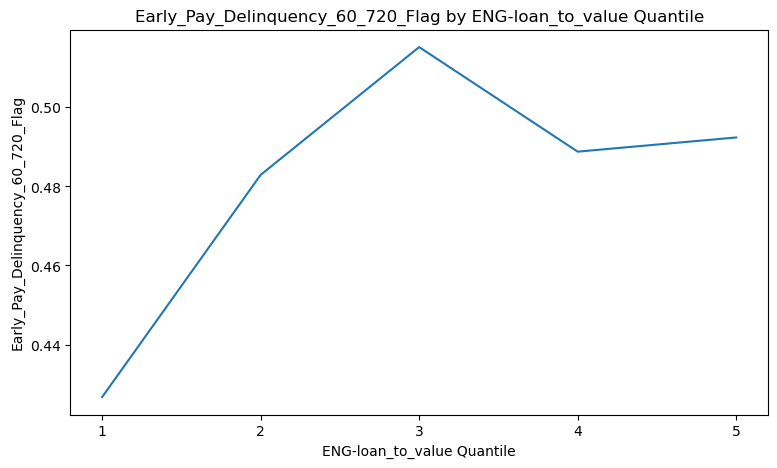

In [27]:
# get quantile
str_col = 'ENG-loan_to_value'
int_n_quantiles = 5
target_by_feature_quantile(
    df=df,
    str_col=str_col,
    int_n_quantiles=int_n_quantiles,
    str_target=str_target,
)

#### Target by Income Quantile

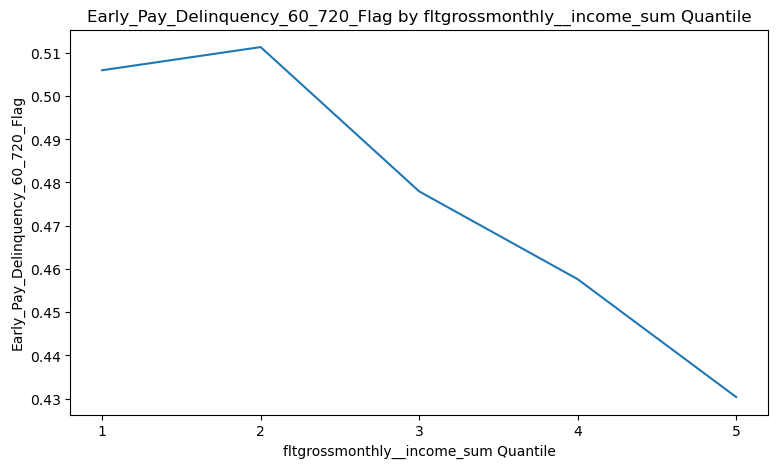

In [28]:
# get quantile
str_col = 'fltgrossmonthly__income_sum'
int_n_quantiles = 5
target_by_feature_quantile(
    df=df,
    str_col=str_col,
    int_n_quantiles=int_n_quantiles,
    str_target=str_target,
)

#### Target by PTI Quantile

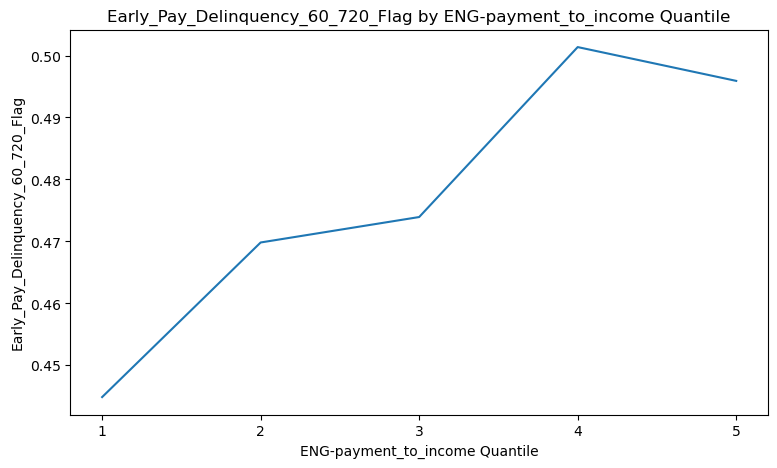

In [29]:
# get quantile
str_col = 'ENG-payment_to_income'
int_n_quantiles = 5
target_by_feature_quantile(
    df=df,
    str_col=str_col,
    int_n_quantiles=int_n_quantiles,
    str_target=str_target,
)

#### List of columns in model

In [30]:
# structure
list_cols_structure = [
    'fltgrossmonthly__income_sum', # income
    'ENG-franchise',
    'ENG-has_codebtor',
    'ENG-vehicle_age', # vehicle age
    'ENG-payment_to_income', # payment to income
    'ENG-loan_to_value', # loan to value
    'ENG-bk', # bk
    'dti__app', # debt to income
]

In [31]:
# pmt history
list_cols_pmt_hx = [
    # pmt hx
    'flt_mean_months_to_first_bad__tu_pmthx', # avg proportion of months to first bad pmt (low is bad)
    # open
    'flt_payment_open__tu_pmthx',
    'int_n_months_open__tu_pmthx',
    'flt_wtd_avg_open__tu_pmthx', # weighted avg of most recent open (low is bad)
    'flt_avg_open__tu_pmthx', # avg of most recent open (low is bad)
    'int_30dpd_open__tu_pmthx', # n times 30 dpd of most recent open
    'int_60dpd_open__tu_pmthx', # n times 60 dpd of most recent open
    'int_90dpd_open__tu_pmthx', # n times 90 dpd of most recent open
    # closed
    'int_n_months_closed__tu_pmthx',
    'flt_wtd_avg_closed__tu_pmthx',
    'flt_avg_closed__tu_pmthx',
    'int_30dpd_closed__tu_pmthx',
    'int_60dpd_closed__tu_pmthx',
    'int_90dpd_closed__tu_pmthx',
    # handpicked
    're01s__tu', # top feature in PD
    'g990s__tu', # highest shap in PD
    'g106s__tu', # in all 4 scorecards
    'addrinputtimenewest__ln', # Time on file (in months) since the subject was most recently reported at the input address
    'linka029__tu', # checking account inquiries
    'au25s__tu',
    'au27s__tu',
    'g980s__tu',
    'bkc321__tu',
    'balmag01__tu',
    'at28b__tu',
    'addrlastmovetaxratiodiff__ln',
    'at35a__tu',
]

In [32]:
# combine lists
#list_cols_model = list_cols_structure + list_cols_pmt_hx + list_cols_tu
list_cols_model = list_cols_structure + list_cols_pmt_hx
print(f'There are {len(list_cols_model)} starting features')

There are 35 starting features


In [33]:
# show the duplicates
ser_freq = pd.Series(list_cols_model).value_counts()
ser_freq = ser_freq[ser_freq > 1]
dict_freq = dict(ser_freq)
print('Duplicate Columns:')
a = 1
for key, val in dict_freq.items():
    print(f'{a}: {key}: {val}')
    a += 1
print('')
# rm dups
list_cols_model = list(dict.fromkeys(list_cols_model))
# make copy
list_cols_model_original = list_cols_model.copy()
# show
print('All Unique Columns:')
for a, col in enumerate(list_cols_model):
    try:
        str_description = dict_map_descriptions[col]
    except KeyError:
        str_description = 'NaN'
    print(f'{a+1}: {col} - {str_description}')

Duplicate Columns:

All Unique Columns:
1: fltgrossmonthly__income_sum - NaN
2: ENG-franchise - NaN
3: ENG-has_codebtor - NaN
4: ENG-vehicle_age - NaN
5: ENG-payment_to_income - NaN
6: ENG-loan_to_value - NaN
7: ENG-bk - NaN
8: dti__app - NaN
9: flt_mean_months_to_first_bad__tu_pmthx - NaN
10: flt_payment_open__tu_pmthx - NaN
11: int_n_months_open__tu_pmthx - NaN
12: flt_wtd_avg_open__tu_pmthx - NaN
13: flt_avg_open__tu_pmthx - NaN
14: int_30dpd_open__tu_pmthx - NaN
15: int_60dpd_open__tu_pmthx - NaN
16: int_90dpd_open__tu_pmthx - NaN
17: int_n_months_closed__tu_pmthx - NaN
18: flt_wtd_avg_closed__tu_pmthx - NaN
19: flt_avg_closed__tu_pmthx - NaN
20: int_30dpd_closed__tu_pmthx - NaN
21: int_60dpd_closed__tu_pmthx - NaN
22: int_90dpd_closed__tu_pmthx - NaN
23: re01s__tu - Number of revolving trades
24: g990s__tu - Number of deduped inquiries in past 12 months
25: g106s__tu - Months on file
26: addrinputtimenewest__ln - Time on file (in months) since the subject was most recently reporte

#### Get relationship with target in training data

In [34]:
int_n_quantiles = 5
df_tmp = get_suggested_constraints(
    df=df[df['data_set'] == 'train'].copy(),
    list_cols_model=list_cols_model,
    str_target=str_target,
    int_n_quantiles=int_n_quantiles,
)
# map data dictionary
df_tmp['description'] = df_tmp['feature'].map(dict_map_descriptions)
# show
df_tmp

 34%|███▍      | 12/35 [00:00<00:00, 54.53it/s]/tmp/ipykernel_4655/2581231829.py:33: RankWarning: Polyfit may be poorly conditioned
  flt_slope, flt_intercept = np.polyfit(x=df_tmp['rank'], y=df_tmp[str_target], deg=1)
/tmp/ipykernel_4655/2581231829.py:33: RankWarning: Polyfit may be poorly conditioned
  flt_slope, flt_intercept = np.polyfit(x=df_tmp['rank'], y=df_tmp[str_target], deg=1)
 51%|█████▏    | 18/35 [00:00<00:00, 55.08it/s]/tmp/ipykernel_4655/2581231829.py:33: RankWarning: Polyfit may be poorly conditioned
  flt_slope, flt_intercept = np.polyfit(x=df_tmp['rank'], y=df_tmp[str_target], deg=1)
100%|██████████| 35/35 [00:00<00:00, 52.28it/s]


,feature,intercept,slope,constraint,imputation,description
0,fltgrossmonthly__income_sum,0.538157,-0.020504,-1,min,NaN
1,ENG-franchise,0.496778,-0.000016,-1,min,NaN
2,ENG-has_codebtor,0.454892,0.000004,1,max,NaN
3,ENG-vehicle_age,0.459927,0.008071,1,max,NaN
4,ENG-payment_to_income,0.437070,0.013368,1,max,NaN
5,ENG-loan_to_value,0.440071,0.013703,1,max,NaN
6,ENG-bk,0.502895,-0.000019,-1,min,NaN
7,dti__app,0.394543,0.028855,1,max,NaN
8,flt_mean_months_to_first_bad__tu_pmthx,0.556269,-0.031649,-1,min,NaN
9,flt_payment_open__tu_pmthx,0.467542,0.002965,1,max,NaN


#### Create monotone constraints dictionary for later

In [35]:
dict_monotone_constraints = dict(zip(df_tmp['feature'], df_tmp['constraint']))
# show
dict_monotone_constraints

{'fltgrossmonthly__income_sum': -1,
 'ENG-franchise': -1,
 'ENG-has_codebtor': 1,
 'ENG-vehicle_age': 1,
 'ENG-payment_to_income': 1,
 'ENG-loan_to_value': 1,
 'ENG-bk': -1,
 'dti__app': 1,
 'flt_mean_months_to_first_bad__tu_pmthx': -1,
 'flt_payment_open__tu_pmthx': 1,
 'int_n_months_open__tu_pmthx': -1,
 'flt_wtd_avg_open__tu_pmthx': -1,
 'flt_avg_open__tu_pmthx': -1,
 'int_30dpd_open__tu_pmthx': 1,
 'int_60dpd_open__tu_pmthx': 1,
 'int_90dpd_open__tu_pmthx': 1,
 'int_n_months_closed__tu_pmthx': -1,
 'flt_wtd_avg_closed__tu_pmthx': -1,
 'flt_avg_closed__tu_pmthx': -1,
 'int_30dpd_closed__tu_pmthx': 1,
 'int_60dpd_closed__tu_pmthx': 1,
 'int_90dpd_closed__tu_pmthx': 1,
 're01s__tu': -1,
 'g990s__tu': 1,
 'g106s__tu': -1,
 'addrinputtimenewest__ln': 1,
 'linka029__tu': 1,
 'au25s__tu': -1,
 'au27s__tu': -1,
 'g980s__tu': 1,
 'bkc321__tu': -1,
 'balmag01__tu': 1,
 'at28b__tu': 1,
 'addrlastmovetaxratiodiff__ln': -1,
 'at35a__tu': 1}

#### Create dictionary for imputation type

In [36]:
dict_impute_type = dict(zip(df_tmp['feature'], df_tmp['imputation']))
# create an imputation dictionary
dict_impute = {}
df_train = df[df['data_set'] == 'train'].copy()
for key, val in tqdm(dict_impute_type.items()):
    # replace any infs with nan
    df_train[key] = df_train[key].replace(np.inf, np.nan)
    # logic
    if val == 'min':
        flt_val = df_train[key].min()
    else:
        flt_val = df_train[key].max()
    # assign
    dict_impute[key] = flt_val
# save memory
del df_train
# show
dict_impute

100%|██████████| 35/35 [00:00<00:00, 965.71it/s]


{'fltgrossmonthly__income_sum': 0.0,
 'ENG-franchise': 0,
 'ENG-has_codebtor': 1,
 'ENG-vehicle_age': 11,
 'ENG-payment_to_income': 1.6556,
 'ENG-loan_to_value': 2.55,
 'ENG-bk': 0,
 'dti__app': 6.717424205438657,
 'flt_mean_months_to_first_bad__tu_pmthx': 0.0,
 'flt_payment_open__tu_pmthx': 9055.0,
 'int_n_months_open__tu_pmthx': 0.0,
 'flt_wtd_avg_open__tu_pmthx': 0.0,
 'flt_avg_open__tu_pmthx': 0.0,
 'int_30dpd_open__tu_pmthx': 47.0,
 'int_60dpd_open__tu_pmthx': 42.0,
 'int_90dpd_open__tu_pmthx': 72.0,
 'int_n_months_closed__tu_pmthx': 0.0,
 'flt_wtd_avg_closed__tu_pmthx': 0.0,
 'flt_avg_closed__tu_pmthx': 0.0,
 'int_30dpd_closed__tu_pmthx': 49.0,
 'int_60dpd_closed__tu_pmthx': 34.0,
 'int_90dpd_closed__tu_pmthx': 52.0,
 're01s__tu': -4.0,
 'g990s__tu': 52.0,
 'g106s__tu': 0.0,
 'addrinputtimenewest__ln': 271.0,
 'linka029__tu': 99.0,
 'au25s__tu': -6.0,
 'au27s__tu': -6.0,
 'g980s__tu': 38.0,
 'bkc321__tu': -6.0,
 'balmag01__tu': 600.0,
 'at28b__tu': 444129.0,
 'addrlastmovetaxrati

In [37]:
# impute
for key, val in tqdm(dict_impute.items()):
    # replace any infs with nan
    df[key] = df[key].replace(np.inf, np.nan)
    # fillna
    df[key] = df[key].fillna(val)
# show
df

100%|██████████| 35/35 [00:00<00:00, 626.91it/s]


,data_set,days_on_books,applicationdate__app,accountid,strdealershiptrackertype__app,bitdebtor__app,Early_Pay_Delinquency_60_720_Flag,fltgrossmonthly__income_sum,flt_payment_open__tu_pmthx,ENG-franchise,...,addrinputtimenewest__ln,linka029__tu,au25s__tu,au27s__tu,g980s__tu,bkc321__tu,balmag01__tu,at28b__tu,addrlastmovetaxratiodiff__ln,at35a__tu
175,train,1215,2021-07-22 17:37:28.093,5716209,Franchise,1,0,7000.0,9055.0,1,...,1.0,2.0,-1.0,-1.0,1.0,1.0,392.0,9325.0,0.0,3198.0
154,train,1215,2021-07-07 12:49:20.480,5702150,Franchise,1,0,7500.0,9055.0,1,...,1.0,0.0,-3.0,-3.0,3.0,103.0,415.0,5775.0,-1.0,1015.0
18,train,1218,2021-07-07 12:17:51.430,5702106,Franchise,1,0,8500.0,9055.0,1,...,1.0,99.0,-3.0,-3.0,1.0,-1.0,-2.0,-3.0,-1.0,-3.0
207,train,1215,2021-07-21 13:45:49.677,5714824,Franchise,0,1,4500.0,501.0,1,...,1.0,4.0,1.0,-6.0,5.0,-1.0,94.0,21829.0,0.0,9729.0
206,train,1215,2021-07-21 13:45:49.677,5714824,Franchise,1,1,3500.0,364.0,1,...,1.0,5.0,-3.0,-3.0,4.0,-2.0,-2.0,-3.0,0.0,-3.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
42089,holdout,721,2022-11-28 12:25:18.957,6464887,Franchise,1,0,5000.0,9055.0,1,...,1.0,1.0,-3.0,-3.0,5.0,170.0,204.0,3250.0,-1.0,165.0
42197,holdout,720,2022-11-28 11:17:53.530,6464638,Independent,1,0,3000.0,9055.0,0,...,-1.0,1.0,-3.0,-3.0,5.0,319.0,254.0,54160.0,-1.0,4152.0
41923,holdout,725,2022-11-28 10:17:32.573,6464416,Independent,1,0,4000.0,713.0,0,...,26.0,0.0,1.0,1.0,1.0,-2.0,34.0,25727.0,0.0,9519.0
42062,holdout,722,2022-11-28 15:09:59.617,6465473,Franchise,1,0,4000.0,9055.0,1,...,-1.0,99.0,-3.0,-3.0,1.0,-1.0,300.0,-3.0,0.0,-3.0


#### Get proportion missing by column by data set

In [38]:
list_dict_row = []
for col in tqdm(list_cols_model):
    dict_row = {'feature': col}
    for str_df in ['train','test','holdout']:
        flt_propna = df[df['data_set'] == str_df][col].isnull().mean()
        # assign
        dict_row[str_df] = flt_propna
    # append
    list_dict_row.append(dict_row)
# make df
df_tmp = pd.DataFrame(list_dict_row)
# get max
df_tmp['max'] = df_tmp[['train','test','holdout']].max(axis=1)
# map
df_tmp['description'] = df_tmp['feature'].map(dict_map_descriptions)
# show
df_tmp.sort_values(by='max', ascending=False, inplace=True)
df_tmp

100%|██████████| 35/35 [00:00<00:00, 77.91it/s]


,feature,train,test,holdout,max,description
0,fltgrossmonthly__income_sum,0.0,NaN,0.0,0.0,NaN
1,ENG-franchise,0.0,NaN,0.0,0.0,NaN
2,ENG-has_codebtor,0.0,NaN,0.0,0.0,NaN
3,ENG-vehicle_age,0.0,NaN,0.0,0.0,NaN
4,ENG-payment_to_income,0.0,NaN,0.0,0.0,NaN
5,ENG-loan_to_value,0.0,NaN,0.0,0.0,NaN
6,ENG-bk,0.0,NaN,0.0,0.0,NaN
7,dti__app,0.0,NaN,0.0,0.0,NaN
8,flt_mean_months_to_first_bad__tu_pmthx,0.0,NaN,0.0,0.0,NaN
9,flt_payment_open__tu_pmthx,0.0,NaN,0.0,0.0,NaN


#### Show the features that are 100% NaN

In [39]:
df_all_nan = df_tmp[df_tmp['max'] == 1].copy()
# get list
list_str_all_nan = list(df_all_nan['feature'])
print(f'There are {len(list_str_all_nan)} features 100% missing')
# show
df_all_nan

There are 0 features 100% missing


,feature,train,test,holdout,max,description


#### Remove all nan features

In [40]:
# df_tmp = df_tmp[~df_tmp['feature'].isin(list_str_all_nan)].copy()
# # get list
# list_cols = list(df_tmp[pd.notnull(df_tmp['description'])]['feature'])
# print(f'There are {len(list_cols)} features remaining')
# # show
# df_tmp

#### Fill missing with -1

In [41]:
# df = df.fillna(-1)
# # show
# df

#### Show proportion missing

In [42]:
ser_isnull = df.isnull().mean()
ser_isnull[ser_isnull > 0]

Series([], dtype: float64)

#### Get info from holdout set

In [43]:
# get the inform data set
df_inform = df[df['data_set'] == 'holdout'].copy()
# get target value
flt_target_value = df_inform[str_target].mean()
print(f'Target Value: {flt_target_value:0.4f}')

Target Value: 0.4204


#### Get train to match the inform set

In [44]:
%%time

# get the training data
df_train = df[df['data_set'] == 'train'].copy()
# get current target mean
flt_current_value = df_train[str_target].mean()
print(f'Target Value Before Sampling: {flt_current_value:0.4f}')
# init
cls_sample = OverSampling(
    df=df_train,
    str_target=str_target,
    flt_target_value=flt_target_value,
    flt_current_value=flt_current_value,
)
# sample
df_train = cls_sample.sample()
# get current target mean
flt_current_value = df_train[str_target].mean()
print(f'Target Value After Sampling: {flt_current_value:0.4f}')
print()
# show
df_train

Target Value Before Sampling: 0.4811
Target Value After Sampling: 0.4204

CPU times: user 36.9 ms, sys: 12.3 ms, total: 49.1 ms
Wall time: 48.7 ms


,data_set,days_on_books,applicationdate__app,accountid,strdealershiptrackertype__app,bitdebtor__app,Early_Pay_Delinquency_60_720_Flag,fltgrossmonthly__income_sum,flt_payment_open__tu_pmthx,ENG-franchise,...,addrinputtimenewest__ln,linka029__tu,au25s__tu,au27s__tu,g980s__tu,bkc321__tu,balmag01__tu,at28b__tu,addrlastmovetaxratiodiff__ln,at35a__tu
12288,train,1008,2022-02-04 13:30:14.720,5918473,Franchise,1,0,6000.0,9055.0,1,...,1.0,0.0,-3.0,-3.0,2.0,-1.0,600.0,-3.0,0.0,-3.0
11007,train,1028,2022-01-20 18:10:11.880,5902793,Franchise,1,1,7000.0,9055.0,1,...,-1.0,99.0,-3.0,-3.0,2.0,-1.0,394.0,1200.0,-1.0,1322.0
5606,train,1118,2021-10-30 11:25:19.720,5811880,Franchise,0,0,2000.0,9055.0,1,...,1.0,0.0,-3.0,-3.0,2.0,103.0,262.0,7530.0,-1.0,575.0
29341,train,833,2022-08-06 11:57:54.727,6222824,Independent,0,0,2500.0,431.0,0,...,1.0,99.0,0.0,0.0,3.0,-2.0,414.0,32064.0,-1.0,18125.0
15975,train,966,2022-03-18 12:50:28.403,5977896,Franchise,1,0,3000.0,429.0,1,...,-1.0,5.0,-6.0,-6.0,1.0,-1.0,219.0,14009.0,-1.0,12874.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
12374,train,1007,2022-02-18 16:50:58.570,5935368,Independent,0,0,2500.0,9055.0,0,...,-1.0,1.0,-3.0,-3.0,1.0,-1.0,-2.0,-3.0,-1.0,-3.0
22645,train,901,2022-06-01 11:35:47.537,6092651,Franchise,1,0,3500.0,384.0,1,...,1.0,2.0,1.0,1.0,7.0,12.0,12.0,11162.0,0.0,2445.0
32195,train,805,2022-08-22 17:30:17.677,6269340,Franchise,1,0,5000.0,9055.0,1,...,129.0,99.0,-1.0,-1.0,1.0,-1.0,-2.0,-3.0,-1.0,-3.0
2384,train,1154,2021-09-18 15:03:26.933,5768425,Franchise,1,0,6000.0,9055.0,1,...,1.0,0.0,-3.0,-3.0,2.0,39.0,312.0,1200.0,0.0,429.0


#### List of columns to start

In [45]:
#list_cols_model_original = list_cols_structure + list_cols_pmt_hx + list_cols
print(f'Starting with {len(list_cols_model_original)} features:')
for a, col in enumerate(list_cols_model_original):
    print(f'{a+1}: {col}')

Starting with 35 features:
1: fltgrossmonthly__income_sum
2: ENG-franchise
3: ENG-has_codebtor
4: ENG-vehicle_age
5: ENG-payment_to_income
6: ENG-loan_to_value
7: ENG-bk
8: dti__app
9: flt_mean_months_to_first_bad__tu_pmthx
10: flt_payment_open__tu_pmthx
11: int_n_months_open__tu_pmthx
12: flt_wtd_avg_open__tu_pmthx
13: flt_avg_open__tu_pmthx
14: int_30dpd_open__tu_pmthx
15: int_60dpd_open__tu_pmthx
16: int_90dpd_open__tu_pmthx
17: int_n_months_closed__tu_pmthx
18: flt_wtd_avg_closed__tu_pmthx
19: flt_avg_closed__tu_pmthx
20: int_30dpd_closed__tu_pmthx
21: int_60dpd_closed__tu_pmthx
22: int_90dpd_closed__tu_pmthx
23: re01s__tu
24: g990s__tu
25: g106s__tu
26: addrinputtimenewest__ln
27: linka029__tu
28: au25s__tu
29: au27s__tu
30: g980s__tu
31: bkc321__tu
32: balmag01__tu
33: at28b__tu
34: addrlastmovetaxratiodiff__ln
35: at35a__tu


#### Get holdout data

In [46]:
# holdout
X_holdout = df[df['data_set'] == 'holdout'][list_cols_model_original].copy()
y_holdout = df[df['data_set'] == 'holdout'][str_target]

#### X, y split

In [47]:
# rm holdout
df = df[df['data_set'] != 'holdout'].copy()
# X
X = df[list_cols_model_original].copy()
# y
y = df[str_target]
# save memory
del df
# show
X

,fltgrossmonthly__income_sum,ENG-franchise,ENG-has_codebtor,ENG-vehicle_age,ENG-payment_to_income,ENG-loan_to_value,ENG-bk,dti__app,flt_mean_months_to_first_bad__tu_pmthx,flt_payment_open__tu_pmthx,...,addrinputtimenewest__ln,linka029__tu,au25s__tu,au27s__tu,g980s__tu,bkc321__tu,balmag01__tu,at28b__tu,addrlastmovetaxratiodiff__ln,at35a__tu
175,7000.0,1,0,3,1.655600,1.444444,0,0.333506,0.000000,9055.0,...,1.0,2.0,-1.0,-1.0,1.0,1.0,392.0,9325.0,0.0,3198.0
154,7500.0,1,0,4,1.655600,0.936170,1,0.284227,0.343892,9055.0,...,1.0,0.0,-3.0,-3.0,3.0,103.0,415.0,5775.0,-1.0,1015.0
18,8500.0,1,0,2,1.655600,1.340426,0,0.443019,0.000000,9055.0,...,1.0,99.0,-3.0,-3.0,1.0,-1.0,-2.0,-3.0,-1.0,-3.0
207,4500.0,1,1,7,0.111333,1.166667,0,0.372575,0.677419,501.0,...,1.0,4.0,1.0,-6.0,5.0,-1.0,94.0,21829.0,0.0,9729.0
206,3500.0,1,1,7,0.104000,1.166667,0,0.372575,0.519231,364.0,...,1.0,5.0,-3.0,-3.0,4.0,-2.0,-2.0,-3.0,0.0,-3.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
31337,0.0,0,1,5,1.655600,1.560000,0,0.277590,0.444236,9055.0,...,1.0,0.0,-3.0,-3.0,1.0,-1.0,222.0,1136.0,-1.0,0.0
31232,4000.0,1,1,5,1.655600,1.400000,0,0.372338,0.000000,9055.0,...,1.0,1.0,-1.0,-1.0,2.0,-1.0,-2.0,4750.0,-1.0,4750.0
31174,4500.0,1,0,5,1.655600,1.413793,0,0.408913,0.525862,9055.0,...,1.0,0.0,-3.0,-3.0,1.0,-2.0,279.0,49484.0,-1.0,18926.0
31271,7000.0,1,1,2,0.079000,1.350000,0,0.380673,0.510000,553.0,...,1.0,1.0,1.0,-6.0,1.0,-1.0,133.0,28697.0,0.0,23811.0


#### Train/test split

In [48]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    random_state=42,
    test_size=0.25,
    shuffle=True,
)
# save memory
del X, y
# show
X_train

,fltgrossmonthly__income_sum,ENG-franchise,ENG-has_codebtor,ENG-vehicle_age,ENG-payment_to_income,ENG-loan_to_value,ENG-bk,dti__app,flt_mean_months_to_first_bad__tu_pmthx,flt_payment_open__tu_pmthx,...,addrinputtimenewest__ln,linka029__tu,au25s__tu,au27s__tu,g980s__tu,bkc321__tu,balmag01__tu,at28b__tu,addrlastmovetaxratiodiff__ln,at35a__tu
5644,3000.0,1,1,5,0.157000,1.454545,0,0.344434,1.000000,471.0,...,1.0,1.0,0.0,-6.0,6.0,75.0,258.0,31452.0,-1.0,6986.0
10991,2500.0,0,1,9,0.127200,1.290323,0,0.468460,0.733333,318.0,...,1.0,2.0,-3.0,-3.0,4.0,157.0,368.0,6147.0,0.0,1281.0
18188,6000.0,1,0,6,1.655600,1.541667,0,0.297594,0.012346,9055.0,...,1.0,0.0,-3.0,-3.0,1.0,-1.0,124.0,5000.0,-1.0,4093.0
6882,2500.0,1,1,4,1.655600,1.371429,0,0.257103,0.018868,9055.0,...,27.0,0.0,-3.0,-3.0,1.0,0.0,324.0,800.0,-1.0,369.0
13700,5500.0,1,0,7,1.655600,1.310345,0,0.327207,0.000000,9055.0,...,1.0,2.0,-1.0,-1.0,5.0,0.0,298.0,1045.0,0.0,1088.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
18865,4000.0,1,0,3,1.655600,1.222222,1,0.464280,0.000000,9055.0,...,1.0,99.0,-1.0,-1.0,1.0,-2.0,-2.0,-3.0,-1.0,-3.0
6516,4500.0,0,1,1,0.115778,1.232558,0,0.476387,1.000000,521.0,...,1.0,1.0,1.0,1.0,3.0,-2.0,134.0,45573.0,0.0,5362.0
12496,3000.0,1,1,0,1.655600,0.975610,0,0.576968,0.000000,9055.0,...,1.0,0.0,-1.0,-1.0,2.0,80.0,356.0,1500.0,0.0,276.0
215,3000.0,1,0,6,1.655600,1.277778,1,0.431778,0.861111,9055.0,...,1.0,0.0,-3.0,-3.0,4.0,-2.0,306.0,250.0,-1.0,0.0


#### Monotone constraints

In [49]:
dict_monotone_constraints

{'fltgrossmonthly__income_sum': -1,
 'ENG-franchise': -1,
 'ENG-has_codebtor': 1,
 'ENG-vehicle_age': 1,
 'ENG-payment_to_income': 1,
 'ENG-loan_to_value': 1,
 'ENG-bk': -1,
 'dti__app': 1,
 'flt_mean_months_to_first_bad__tu_pmthx': -1,
 'flt_payment_open__tu_pmthx': 1,
 'int_n_months_open__tu_pmthx': -1,
 'flt_wtd_avg_open__tu_pmthx': -1,
 'flt_avg_open__tu_pmthx': -1,
 'int_30dpd_open__tu_pmthx': 1,
 'int_60dpd_open__tu_pmthx': 1,
 'int_90dpd_open__tu_pmthx': 1,
 'int_n_months_closed__tu_pmthx': -1,
 'flt_wtd_avg_closed__tu_pmthx': -1,
 'flt_avg_closed__tu_pmthx': -1,
 'int_30dpd_closed__tu_pmthx': 1,
 'int_60dpd_closed__tu_pmthx': 1,
 'int_90dpd_closed__tu_pmthx': 1,
 're01s__tu': -1,
 'g990s__tu': 1,
 'g106s__tu': -1,
 'addrinputtimenewest__ln': 1,
 'linka029__tu': 1,
 'au25s__tu': -1,
 'au27s__tu': -1,
 'g980s__tu': 1,
 'bkc321__tu': -1,
 'balmag01__tu': 1,
 'at28b__tu': 1,
 'addrlastmovetaxratiodiff__ln': -1,
 'at35a__tu': 1}

#### XGBoost - Feature Selection

In [50]:
%%time

list_cols_model = list_cols_model_original.copy()
X_train_tmp = X_train.copy()
X_test_tmp = X_test.copy()

list_dict_row = []
counter = 0
while True:
    # tmp
    X_train_tmp = X_train_tmp[list_cols_model].copy()
    X_test_tmp = X_test_tmp[list_cols_model].copy()
    
    # ensure features are in list_cols_model
    dict_monotone_constraints = {key: val for key, val in dict_monotone_constraints.items() if key in list_cols_model}
    
    # init model
    cls_model_inference = xbm.XGBClassifier(
        n_estimators=int_n_iterations,
        early_stopping_rounds=int_n_early_stopping,
        eval_metric='auc',
        monotone_constraints=dict_monotone_constraints,
    )
    # fit
    cls_model_inference.fit(
        X=X_train_tmp,
        y=y_train,
        eval_set=[(X_test_tmp, y_test)],
        verbose=False,
    )
    
    # get predictions
    y_hat_train = cls_model_inference.predict_proba(X_train_tmp)[:,1]
    y_hat_valid = cls_model_inference.predict_proba(X_test_tmp)[:,1]
    y_hat_holdout = cls_model_inference.predict_proba(X_holdout[list_cols_model])[:,1]
    
    # get the training eval metric
    flt_eval_metric_train = skm.roc_auc_score(y_true=y_train, y_score=y_hat_train)
    # get valid eval metric
    flt_eval_metric_valid = skm.roc_auc_score(y_true=y_test, y_score=y_hat_valid)
    # get holdout eval metric
    flt_eval_metric_holdout = skm.roc_auc_score(y_true=y_holdout, y_score=y_hat_holdout)
    
    # make a row
    dict_row = {
        'iteration': counter,
        'flt_eval_metric_train': flt_eval_metric_train,
        'flt_eval_metric_valid': flt_eval_metric_valid,
        'flt_eval_metric_holdout': flt_eval_metric_holdout,
        'list_cols_model': list_cols_model,
        'n_feats': len(list_cols_model),
        'cls_model_inference': cls_model_inference,
    }
    # append
    list_dict_row.append(dict_row)
    
    # get feature importance
    df_feat_imp = get_xgboost_feat_importance(
        cls_model_inference=cls_model_inference,
    )
    
    # remove the bottom n
    int_n_remove = 1
    list_cols_keep = list(df_feat_imp['feature'])[:-int_n_remove]
    
    # break if there are no features
    int_n_keep = 10
    if len(list_cols_keep) < int_n_keep:
        break
        
    # get the features we will not keep
    list_cols_drop = [col for col in list_cols_model if col not in list_cols_keep]
    # get the number of features we will drop
    int_n_dropped = len(list_cols_drop)
    # if there are no features to drop
    if int_n_dropped == 0:
        break
    else:
        list_cols_model = list_cols_keep
        counter += 1
# make df
df_tmp = pd.DataFrame(list_dict_row)
# get scaled score
df_tmp = get_scaled_score(df=df_tmp)
# show
df_tmp

CPU times: user 1min 8s, sys: 541 ms, total: 1min 8s
Wall time: 8.66 s


,iteration,flt_eval_metric_train,flt_eval_metric_valid,flt_eval_metric_holdout,list_cols_model,n_feats,cls_model_inference,flt_eval_metric_valid_scaled,diff,diff_scaled,n_feats_scaled,score
18,18,0.675554,0.654116,0.638578,"[dti__app, ENG-bk, flt_mean_months_to_first_ba...",17,"XGBClassifier(base_score=None, booster=None, c...",0.632224,0.021438,0.719655,0.72,0.675939
20,20,0.675586,0.653959,0.638217,"[dti__app, ENG-bk, flt_mean_months_to_first_ba...",15,"XGBClassifier(base_score=None, booster=None, c...",0.616094,0.021627,0.708022,0.80,0.662058
19,19,0.675937,0.653979,0.638389,"[dti__app, ENG-bk, flt_mean_months_to_first_ba...",16,"XGBClassifier(base_score=None, booster=None, c...",0.618128,0.021957,0.687588,0.76,0.652858
22,22,0.671935,0.652343,0.636635,"[ENG-bk, dti__app, bkc321__tu, balmag01__tu, f...",13,"XGBClassifier(base_score=None, booster=None, c...",0.449709,0.019592,0.833647,0.88,0.641678
17,17,0.680281,0.655296,0.641807,"[dti__app, ENG-bk, g990s__tu, balmag01__tu, fl...",18,"XGBClassifier(base_score=None, booster=None, c...",0.753590,0.024985,0.500599,0.68,0.627095
13,13,0.681021,0.655557,0.640540,"[dti__app, g990s__tu, ENG-bk, bkc321__tu, link...",22,"XGBClassifier(base_score=None, booster=None, c...",0.780488,0.025464,0.471048,0.52,0.625768
5,5,0.686759,0.657690,0.642270,"[dti__app, ENG-bk, bkc321__tu, g990s__tu, balm...",30,"XGBClassifier(base_score=None, booster=None, c...",1.000000,0.029069,0.248418,0.20,0.624209
14,14,0.681775,0.655498,0.640408,"[dti__app, flt_mean_months_to_first_bad__tu_pm...",21,"XGBClassifier(base_score=None, booster=None, c...",0.774427,0.026277,0.420846,0.56,0.597636
6,6,0.684860,0.656537,0.642820,"[dti__app, ENG-bk, g990s__tu, bkc321__tu, balm...",29,"XGBClassifier(base_score=None, booster=None, c...",0.881336,0.028323,0.294509,0.24,0.587922
10,10,0.685121,0.656514,0.642144,"[dti__app, ENG-bk, g990s__tu, balmag01__tu, bk...",25,"XGBClassifier(base_score=None, booster=None, c...",0.879006,0.028607,0.276946,0.40,0.577976


#### Evaluate best model

In [51]:
cls_model_inference = df_tmp['cls_model_inference'].iloc[0]
list_cols_model_xgboost = cls_model_inference.feature_names_in_
for a, col in enumerate(list_cols_model_xgboost):
    print(f'{a+1}: {col}')

1: dti__app
2: ENG-bk
3: flt_mean_months_to_first_bad__tu_pmthx
4: balmag01__tu
5: g990s__tu
6: bkc321__tu
7: re01s__tu
8: flt_wtd_avg_closed__tu_pmthx
9: g106s__tu
10: linka029__tu
11: flt_avg_closed__tu_pmthx
12: ENG-franchise
13: ENG-loan_to_value
14: int_n_months_closed__tu_pmthx
15: int_n_months_open__tu_pmthx
16: int_60dpd_open__tu_pmthx
17: flt_avg_open__tu_pmthx


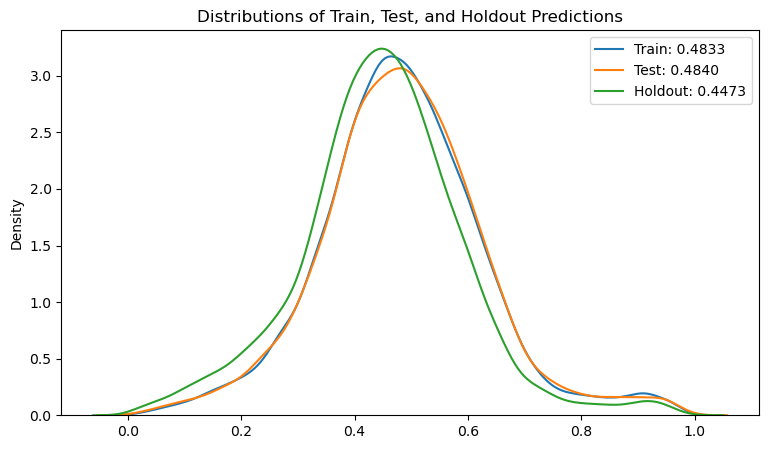

In [52]:
# get predictions
list_predictions_train = list(cls_model_inference.predict_proba(X_train[list_cols_model_xgboost])[:,1])
list_predictions_test = list(cls_model_inference.predict_proba(X_test[list_cols_model_xgboost])[:,1])
list_predictions_holdout = list(cls_model_inference.predict_proba(X_holdout[list_cols_model_xgboost])[:,1])

# plot distributions
fig, ax = plt.subplots(figsize=(9,5))
ax.set_title('Distributions of Train, Test, and Holdout Predictions')
sns.kdeplot(list_predictions_train, label=f'Train: {np.mean(list_predictions_train):0.4f}')
sns.kdeplot(list_predictions_test, label=f'Test: {np.mean(list_predictions_test):0.4f}')
sns.kdeplot(list_predictions_holdout, label=f'Holdout: {np.mean(list_predictions_holdout):0.4f}')
# legend
ax.legend()
# show
plt.show()

In [53]:
# eval
evaluate(
    y_train=y_train,
    list_predictions_train=list_predictions_train,
    y_test=y_test,
    list_predictions_test=list_predictions_test,
    y_holdout=y_holdout,
    list_predictions_holdout=list_predictions_holdout,
)

AUC Train: 0.6756
AUC Test: 0.6541
AUC Holdout: 0.6386

Logloss Train: 0.6386
Logloss Test: 0.6525
Logloss Holdout: 0.6482

KS Train: 0.2446
KS Test: 0.2194
KS Holdout: 0.1830


#### Check directions of predictions

In [54]:
# int_n_quantiles = 5
# get_directions_of_predictions(
#     X=X_holdout.copy(),
#     list_predictions=list_predictions_holdout,
#     str_target=str_target,
#     list_actual=list(y_holdout),
#     list_cols=list_cols_model_xgboost,
#     int_n_quantiles=int_n_quantiles,
# )

#### Check mean actual by prediction quantile


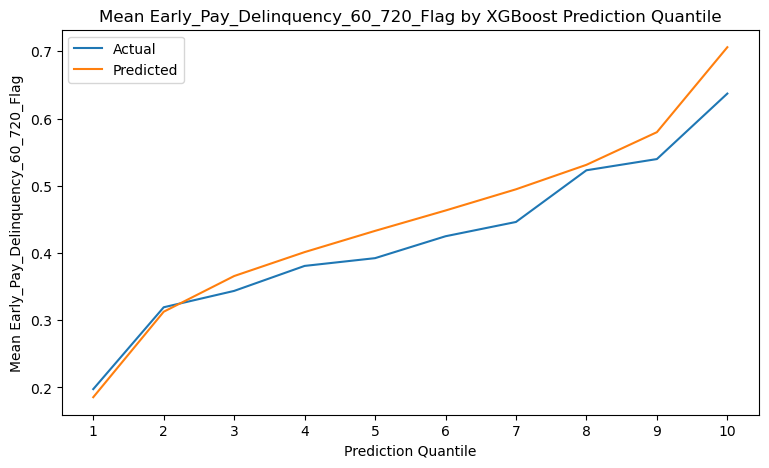

In [55]:
int_n_quantiles = 10
get_mean_actual_by_prediction_quantile(
    X=X_holdout.copy(),
    list_predictions=list_predictions_holdout,
    list_actual=list(y_holdout),
    str_target=str_target,
    int_n_quantiles=int_n_quantiles,
    str_model_type='XGBoost',
)

#### Catboost - Feature Selection

In [56]:
%%time

list_cols_model = list_cols_model_original.copy()
X_train_tmp = X_train.copy()
X_test_tmp = X_test.copy()

list_dict_row = []
counter = 0
while True:
    # tmp
    X_train_tmp = X_train_tmp[list_cols_model].copy()
    X_test_tmp = X_test_tmp[list_cols_model].copy()
    
    # get the non numeric feats
    list_cols_non_numeric = []
    for col in list_cols_model:
        if X_train_tmp[col].dtype not in ['int64','float64']:
            list_cols_non_numeric.append(col)

    # pool data
    pool_train = cb.Pool(
        X_train_tmp, 
        y_train, 
        cat_features=list_cols_non_numeric,
    )
    # pool
    pool_valid = cb.Pool(
        X_test_tmp, 
        y_test, 
        cat_features=list_cols_non_numeric,
    )
    
    # ensure features are in list_cols_model
    dict_monotone_constraints = {key: val for key, val in dict_monotone_constraints.items() if key in list_cols_model}
    # init class
    cls_model_inference = cb.CatBoostClassifier(
        task_type='CPU',
        nan_mode='Min',
        random_state=42,
        eval_metric='AUC',
        iterations=int_n_iterations,
        learning_rate=None,
        class_weights=None,
        monotone_constraints=dict_monotone_constraints,
    )
    # fit
    cls_model_inference.fit(
        pool_train,
        eval_set=[pool_valid],
        verbose=False,
        use_best_model=True,
        early_stopping_rounds=int_n_early_stopping, 
    )
    # get predictions
    y_hat_train = cls_model_inference.predict_proba(pool_train)[:,1]
    y_hat_valid = cls_model_inference.predict_proba(pool_valid)[:,1]
    y_hat_holdout = cls_model_inference.predict_proba(X_holdout[list_cols_model])[:,1]
    
    # get the training eval metric
    flt_eval_metric_train = skm.roc_auc_score(y_true=y_train, y_score=y_hat_train)
    # get valid eval metric
    flt_eval_metric_valid = skm.roc_auc_score(y_true=y_test, y_score=y_hat_valid)
    # get holdout eval metric
    flt_eval_metric_holdout = skm.roc_auc_score(y_true=y_holdout, y_score=y_hat_holdout)
    
    # make a row
    dict_row = {
        'iteration': counter,
        'flt_eval_metric_train': flt_eval_metric_train,
        'flt_eval_metric_valid': flt_eval_metric_valid,
        'flt_eval_metric_holdout': flt_eval_metric_holdout,
        'list_cols_model': list_cols_model,
        'n_feats': len(list_cols_model),
        'cls_model_inference': cls_model_inference,
    }
    # append
    list_dict_row.append(dict_row)

    # get importance
    df_feat_imp = get_catboost_feat_importance(
        cls_model_inference=cls_model_inference,
        pool_eval=pool_valid,
    )
    
    # remove the bottom n
    int_n_remove = 1
    list_cols_keep = list(df_feat_imp['feature'])[:-int_n_remove]
    
    # break if there are no features
    int_n_keep = 10
    if len(list_cols_keep) < int_n_keep:
        break
    
    # get the features we will not keep
    list_cols_drop = [col for col in list_cols_model if col not in list_cols_keep]
    # get the number of features we will drop
    int_n_dropped = len(list_cols_drop)
    # if there are no features to drop
    if int_n_dropped == 0:
        break
    else:
        list_cols_model = list_cols_keep
        counter += 1
# make df
df_tmp = pd.DataFrame(list_dict_row)
# get scaled score
df_tmp = get_scaled_score(df=df_tmp)
# show
df_tmp

CPU times: user 10min 10s, sys: 51.7 s, total: 11min 1s
Wall time: 1min 35s


,iteration,flt_eval_metric_train,flt_eval_metric_valid,flt_eval_metric_holdout,list_cols_model,n_feats,cls_model_inference,flt_eval_metric_valid_scaled,diff,diff_scaled,n_feats_scaled,score
10,10,0.698371,0.670351,0.646687,"[dti__app, balmag01__tu, g990s__tu, re01s__tu,...",25,<catboost.core.CatBoostClassifier object at 0x...,0.951073,0.028020,0.675154,0.40,0.813113
13,13,0.702011,0.669712,0.644980,"[dti__app, balmag01__tu, g990s__tu, re01s__tu,...",22,<catboost.core.CatBoostClassifier object at 0x...,0.916645,0.032298,0.607568,0.52,0.762106
16,16,0.701764,0.669001,0.644299,"[dti__app, balmag01__tu, g990s__tu, int_n_mont...",19,<catboost.core.CatBoostClassifier object at 0x...,0.878313,0.032763,0.600227,0.64,0.739270
15,15,0.706751,0.669327,0.643733,"[dti__app, balmag01__tu, g990s__tu, int_n_mont...",20,<catboost.core.CatBoostClassifier object at 0x...,0.895889,0.037423,0.526600,0.60,0.711245
9,9,0.710667,0.670169,0.646348,"[dti__app, balmag01__tu, g990s__tu, re01s__tu,...",26,<catboost.core.CatBoostClassifier object at 0x...,0.941248,0.040498,0.478025,0.36,0.709636
7,7,0.714359,0.670613,0.646601,"[dti__app, balmag01__tu, g990s__tu, re01s__tu,...",28,<catboost.core.CatBoostClassifier object at 0x...,0.965182,0.043746,0.426710,0.28,0.695946
6,6,0.712407,0.669841,0.646422,"[dti__app, balmag01__tu, g990s__tu, re01s__tu,...",29,<catboost.core.CatBoostClassifier object at 0x...,0.923576,0.042566,0.445364,0.24,0.684470
19,19,0.683071,0.662976,0.642094,"[dti__app, balmag01__tu, g990s__tu, re01s__tu,...",16,<catboost.core.CatBoostClassifier object at 0x...,0.553546,0.020095,0.800361,0.76,0.676953
5,5,0.719954,0.670653,0.646317,"[dti__app, balmag01__tu, g990s__tu, re01s__tu,...",30,<catboost.core.CatBoostClassifier object at 0x...,0.967373,0.049300,0.338968,0.20,0.653171
12,12,0.713240,0.669052,0.645515,"[dti__app, balmag01__tu, g990s__tu, re01s__tu,...",23,<catboost.core.CatBoostClassifier object at 0x...,0.881036,0.044188,0.419734,0.48,0.650385


#### Evaluate best model

In [57]:
cls_model_inference = df_tmp['cls_model_inference'].iloc[0]
list_cols_model_catboost = cls_model_inference.feature_names_
for a, col in enumerate(list_cols_model_catboost):
    print(f'{a+1}: {col}')

1: dti__app
2: balmag01__tu
3: g990s__tu
4: re01s__tu
5: bkc321__tu
6: int_n_months_closed__tu_pmthx
7: g106s__tu
8: ENG-loan_to_value
9: flt_mean_months_to_first_bad__tu_pmthx
10: ENG-bk
11: int_n_months_open__tu_pmthx
12: int_30dpd_open__tu_pmthx
13: ENG-vehicle_age
14: addrinputtimenewest__ln
15: ENG-franchise
16: flt_avg_closed__tu_pmthx
17: flt_avg_open__tu_pmthx
18: linka029__tu
19: flt_wtd_avg_closed__tu_pmthx
20: int_90dpd_open__tu_pmthx
21: flt_wtd_avg_open__tu_pmthx
22: int_30dpd_closed__tu_pmthx
23: ENG-has_codebtor
24: addrlastmovetaxratiodiff__ln
25: au25s__tu


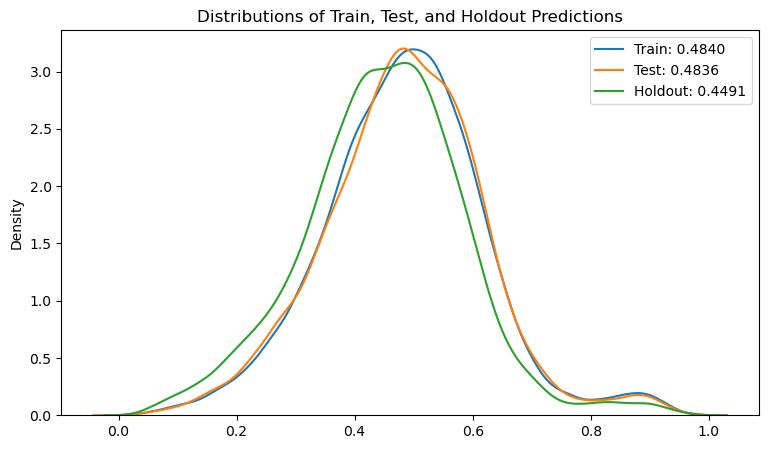

In [58]:
# get predictions
list_predictions_train = list(cls_model_inference.predict_proba(X_train[list_cols_model_catboost])[:,1])
list_predictions_test = list(cls_model_inference.predict_proba(X_test[list_cols_model_catboost])[:,1])
list_predictions_holdout = list(cls_model_inference.predict_proba(X_holdout[list_cols_model_catboost])[:,1])

# plot distributions
fig, ax = plt.subplots(figsize=(9,5))
ax.set_title('Distributions of Train, Test, and Holdout Predictions')
sns.kdeplot(list_predictions_train, label=f'Train: {np.mean(list_predictions_train):0.4f}')
sns.kdeplot(list_predictions_test, label=f'Test: {np.mean(list_predictions_test):0.4f}')
sns.kdeplot(list_predictions_holdout, label=f'Holdout: {np.mean(list_predictions_holdout):0.4f}')
# legend
ax.legend()
# show
plt.show()

In [59]:
# eval
evaluate(
    y_train=y_train,
    list_predictions_train=list_predictions_train,
    y_test=y_test,
    list_predictions_test=list_predictions_test,
    y_holdout=y_holdout,
    list_predictions_holdout=list_predictions_holdout,
)

AUC Train: 0.6984
AUC Test: 0.6704
AUC Holdout: 0.6467

Logloss Train: 0.6300
Logloss Test: 0.6443
Logloss Holdout: 0.6453

KS Train: 0.2755
KS Test: 0.2290
KS Holdout: 0.1969


#### Check directions of predictions


In [60]:
# int_n_quantiles = 5
# get_directions_of_predictions(
#     X=X_holdout,
#     list_predictions=list_predictions_holdout,
#     str_target=str_target,
#     list_actual=list(y_holdout),
#     list_cols=list_cols_model_catboost,
#     int_n_quantiles=int_n_quantiles,
# )

#### Check mean actual by prediction quantile


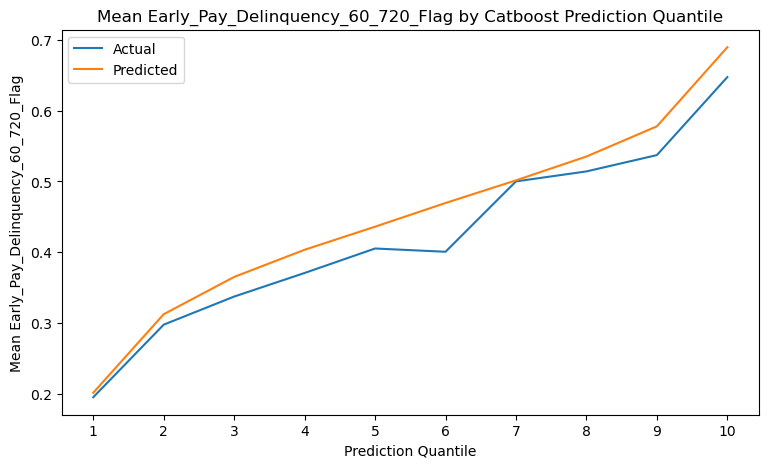

In [61]:
int_n_quantiles = 10
get_mean_actual_by_prediction_quantile(
    X=X_holdout.copy(),
    list_predictions=list_predictions_holdout,
    list_actual=list(y_holdout),
    str_target=str_target,
    int_n_quantiles=int_n_quantiles,
    str_model_type='Catboost',
)

#### Logistic Regression - Feature Selection

In [62]:
# scale
list_cols_model = list_cols_model_original.copy()
# init
cls_scaler = StandardScaler()

In [63]:
# train
X_train_tmp = cls_scaler.fit_transform(X_train[list_cols_model])
X_train_tmp = pd.DataFrame(X_train_tmp, columns=list_cols_model)
ser_isnull = X_train_tmp.isnull().mean()
ser_isnull[ser_isnull > 0]

Series([], dtype: float64)

In [64]:
# test
X_test_tmp = cls_scaler.transform(X_test[list_cols_model])
X_test_tmp = pd.DataFrame(X_test_tmp, columns=list_cols_model)
ser_isnull = X_test_tmp.isnull().mean()
ser_isnull[ser_isnull > 0]

Series([], dtype: float64)

In [65]:
# holdout
X_holdout_tmp = cls_scaler.transform(X_holdout[list_cols_model])
X_holdout_tmp = pd.DataFrame(X_holdout_tmp, columns=list_cols_model)
ser_isnull = X_holdout_tmp.isnull().mean()
ser_isnull[ser_isnull > 0]

Series([], dtype: float64)

In [66]:
%%time

list_dict_row = []
counter = 0
while True:
    # tmp
    X_train_tmp = X_train_tmp[list_cols_model].copy()
    X_test_tmp = X_test_tmp[list_cols_model].copy()
    X_holdout_tmp = X_holdout_tmp[list_cols_model].copy()
        
    # init
    cls_model_inference = LogisticRegression(
        penalty='l2',
        random_state=42,
        fit_intercept=True,
    )
    # fit
    cls_model_inference.fit(X_train_tmp, y_train)
    
    # get predictions
    y_hat_train = cls_model_inference.predict_proba(X_train_tmp)[:,1]
    y_hat_valid = cls_model_inference.predict_proba(X_test_tmp)[:,1]
    y_hat_holdout = cls_model_inference.predict_proba(X_holdout_tmp)[:,1]
    
    # get the training eval metric
    flt_eval_metric_train = skm.roc_auc_score(y_true=y_train, y_score=y_hat_train)
    # get valid eval metric
    flt_eval_metric_valid = skm.roc_auc_score(y_true=y_test, y_score=y_hat_valid)
    # get holdout eval metric
    flt_eval_metric_holdout = skm.roc_auc_score(y_true=y_holdout, y_score=y_hat_holdout)
    
    # make a row
    dict_row = {
        'iteration': counter,
        'flt_eval_metric_train': flt_eval_metric_train,
        'flt_eval_metric_valid': flt_eval_metric_valid,
        'flt_eval_metric_holdout': flt_eval_metric_holdout,
        'list_cols_model': list_cols_model,
        'n_feats': len(list_cols_model),
        'cls_model_inference': cls_model_inference,
    }
    # append
    list_dict_row.append(dict_row)
    
    # get feature importance
    df_feat_imp = get_logistic_regression_feat_importance(
        cls_model_inference=cls_model_inference,
    )
    
    # remove the bottom n
    int_n_remove = 1
    list_cols_keep = list(df_feat_imp['feature'])[:-int_n_remove]
    
    # break if there are no features
    int_n_keep = 10
    if len(list_cols_keep) < int_n_keep:
        break
    
    # get the features we will not keep
    list_cols_drop = [col for col in list_cols_model if col not in list_cols_keep]
    # get the number of features we will drop
    int_n_dropped = len(list_cols_drop)
    # if there are no features to drop
    if int_n_dropped == 0:
        break
    else:
        list_cols_model = list_cols_keep
        counter += 1
# make df
df_tmp = pd.DataFrame(list_dict_row)
# get scaled score
#df_tmp = get_scaled_score(df=df_tmp)
# get the best valid score
df_tmp.sort_values(by='flt_eval_metric_valid', ascending=False, inplace=True)
# show
df_tmp

CPU times: user 10.6 s, sys: 101 ms, total: 10.7 s
Wall time: 2.7 s


,iteration,flt_eval_metric_train,flt_eval_metric_valid,flt_eval_metric_holdout,list_cols_model,n_feats,cls_model_inference
1,1,0.637812,0.652190,0.637112,"[flt_avg_open__tu_pmthx, int_90dpd_open__tu_pm...",34,LogisticRegression(random_state=42)
2,2,0.637811,0.652188,0.637083,"[flt_avg_open__tu_pmthx, int_90dpd_open__tu_pm...",33,LogisticRegression(random_state=42)
4,4,0.637811,0.652162,0.637138,"[flt_avg_open__tu_pmthx, int_90dpd_open__tu_pm...",31,LogisticRegression(random_state=42)
0,0,0.637821,0.652142,0.637101,"[fltgrossmonthly__income_sum, ENG-franchise, E...",35,LogisticRegression(random_state=42)
3,3,0.637797,0.652090,0.637142,"[flt_avg_open__tu_pmthx, int_90dpd_open__tu_pm...",32,LogisticRegression(random_state=42)
5,5,0.637812,0.652076,0.637025,"[flt_avg_open__tu_pmthx, int_90dpd_open__tu_pm...",30,LogisticRegression(random_state=42)
6,6,0.637809,0.651969,0.636857,"[flt_avg_open__tu_pmthx, int_90dpd_open__tu_pm...",29,LogisticRegression(random_state=42)
8,8,0.637936,0.651961,0.636890,"[flt_avg_open__tu_pmthx, int_90dpd_open__tu_pm...",27,LogisticRegression(random_state=42)
7,7,0.637933,0.651950,0.636934,"[flt_avg_open__tu_pmthx, int_90dpd_open__tu_pm...",28,LogisticRegression(random_state=42)
9,9,0.637771,0.651839,0.637008,"[flt_avg_open__tu_pmthx, int_90dpd_open__tu_pm...",26,LogisticRegression(random_state=42)


#### Evaluate best model

In [67]:
cls_model_inference = df_tmp['cls_model_inference'].iloc[0]
list_cols_model_logistic_regression = cls_model_inference.feature_names_in_
# get the importance
df_feat_imp = get_logistic_regression_feat_importance(
    cls_model_inference=cls_model_inference,
)
# map description
df_feat_imp['description'] = df_feat_imp['feature'].map(dict_map_descriptions)
# show
df_feat_imp

,feature,importance,importance_abs,description
0,flt_avg_open__tu_pmthx,-0.561922,0.561922,NaN
1,int_90dpd_open__tu_pmthx,-0.427619,0.427619,NaN
2,dti__app,0.325011,0.325011,NaN
3,flt_wtd_avg_open__tu_pmthx,0.251607,0.251607,NaN
4,g990s__tu,0.202155,0.202155,Number of deduped inquiries in past 12 months
5,re01s__tu,-0.197515,0.197515,Number of revolving trades
6,flt_avg_closed__tu_pmthx,-0.185822,0.185822,NaN
7,int_90dpd_closed__tu_pmthx,-0.164886,0.164886,NaN
8,int_n_months_open__tu_pmthx,-0.160483,0.160483,NaN
9,int_n_months_closed__tu_pmthx,-0.156195,0.156195,NaN


#### Evaluate Logistic Regression Model

In [68]:
# init
cls_scaler = StandardScaler()
# train
X_train_tmp = cls_scaler.fit_transform(X_train[list_cols_model_logistic_regression])
X_train_tmp = pd.DataFrame(X_train_tmp, columns=list_cols_model_logistic_regression)
# test
X_test_tmp = cls_scaler.transform(X_test[list_cols_model_logistic_regression])
X_test_tmp = pd.DataFrame(X_test_tmp, columns=list_cols_model_logistic_regression)
# holdout
X_holdout_tmp = cls_scaler.transform(X_holdout[list_cols_model_logistic_regression])
X_holdout_tmp = pd.DataFrame(X_holdout_tmp, columns=list_cols_model_logistic_regression)

In [69]:
# get predictions
list_predictions_train = list(cls_model_inference.predict_proba(X_train_tmp)[:,1])
list_predictions_test = list(cls_model_inference.predict_proba(X_test_tmp)[:,1])
list_predictions_holdout = list(cls_model_inference.predict_proba(X_holdout_tmp)[:,1])

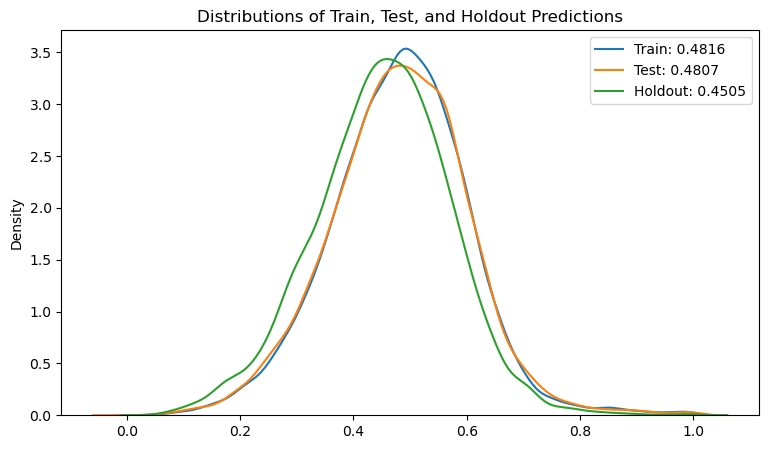

In [70]:
# plot distributions
fig, ax = plt.subplots(figsize=(9,5))
ax.set_title('Distributions of Train, Test, and Holdout Predictions')
sns.kdeplot(list_predictions_train, label=f'Train: {np.mean(list_predictions_train):0.4f}')
sns.kdeplot(list_predictions_test, label=f'Test: {np.mean(list_predictions_test):0.4f}')
sns.kdeplot(list_predictions_holdout, label=f'Holdout: {np.mean(list_predictions_holdout):0.4f}')
# legend
ax.legend()
# show
plt.show()

In [71]:
# eval
evaluate(
    y_train=y_train,
    list_predictions_train=list_predictions_train,
    y_test=y_test,
    list_predictions_test=list_predictions_test,
    y_holdout=y_holdout,
    list_predictions_holdout=list_predictions_holdout,
)

AUC Train: 0.6378
AUC Test: 0.6522
AUC Holdout: 0.6371

Logloss Train: 0.6621
Logloss Test: 0.6580
Logloss Holdout: 0.6522

KS Train: 0.1933
KS Test: 0.2147
KS Holdout: 0.1902


#### Check directions of predictions

In [72]:
# int_n_quantiles = 5
# get_directions_of_predictions(
#     X=X_holdout_tmp.copy(),
#     list_predictions=list_predictions_holdout,
#     str_target=str_target,
#     list_actual=list(y_holdout),
#     list_cols=list_cols_model_logistic_regression,
#     int_n_quantiles=int_n_quantiles,
# )

#### Check mean actual by prediction quantile

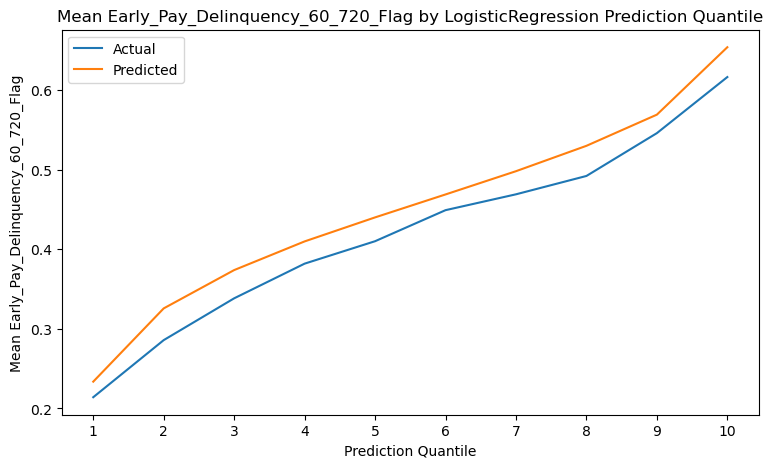

In [73]:
int_n_quantiles = 10
get_mean_actual_by_prediction_quantile(
    X=X_holdout_tmp.copy(),
    list_predictions=list_predictions_holdout,
    list_actual=list(y_holdout),
    str_target=str_target,
    int_n_quantiles=int_n_quantiles,
    str_model_type='LogisticRegression',
)